# Week 3: Baseline Predictive Modeling (Booking Cancellation Prediction)

## Objective
Build a baseline machine learning model to predict hotel booking cancellations.

## Workflow
1. Load Dataset
2. Verify Dataset
3. Select Features
4. Train-Test Split
5. Train Model
6. Evaluate Model

## Libraries Used
- Pandas
- NumPy
- Scikit-Learn

In [1]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\cusac\OneDrive - Thiagarajar School of Management\Desktop\Hotel Bookings Project\Data\hotel_bookings_cleaned.csv"
)

print(df.shape)
df.head()

(84889, 35)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay_nights,total_guests,total_revenue
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,7/1/2015,0,2,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,7/1/2015,0,2,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,7/2/2015,1,1,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,7/2/2015,1,1,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,7/3/2015,2,2,196.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84889 entries, 0 to 84888
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           84889 non-null  object 
 1   is_canceled                     84889 non-null  int64  
 2   lead_time                       84889 non-null  int64  
 3   arrival_date_year               84889 non-null  int64  
 4   arrival_date_month              84889 non-null  object 
 5   arrival_date_week_number        84889 non-null  int64  
 6   arrival_date_day_of_month       84889 non-null  int64  
 7   stays_in_weekend_nights         84889 non-null  int64  
 8   stays_in_week_nights            84889 non-null  int64  
 9   adults                          84889 non-null  int64  
 10  children                        84889 non-null  int64  
 11  babies                          84889 non-null  int64  
 12  meal                            

In [3]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_stay_nights,total_guests,total_revenue
count,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.00000,84889.000000,84889.000000,84889.000000,...,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000
mean,0.271637,80.150444,2016.199637,26.721907,15.798337,1.001319,2.61313,1.866755,0.117683,0.010472,...,0.268822,78.846258,11.307001,0.768250,101.788429,0.082013,0.693541,3.614449,1.994911,373.848770
std,0.444806,86.460475,0.685912,13.812371,8.842121,1.032651,2.05764,0.627788,0.416169,0.112255,...,0.724677,109.037505,54.687341,10.145598,45.205950,0.278223,0.827720,2.767990,0.768068,334.516873
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,-63.800000
25%,0.000000,11.000000,2016.000000,15.000000,8.000000,0.000000,1.00000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,0.000000,71.100000,0.000000,0.000000,2.000000,2.000000,150.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.00000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,0.000000,96.530000,0.000000,0.000000,3.000000,2.000000,291.600000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,3.00000,2.000000,0.000000,0.000000,...,0.000000,195.000000,0.000000,0.000000,130.000000,0.000000,1.000000,5.000000,2.000000,484.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.00000,55.000000,10.000000,10.000000,...,21.000000,535.000000,543.000000,391.000000,227.000000,8.000000,5.000000,69.000000,55.000000,7590.000000


## Dataset Verification

- Dataset loaded successfully.
- Total Records: 84,889
- Total Features: 35
- No missing values found.
- Dataset is ready for predictive modeling.

# Week 3: Baseline Predictive Modeling

## Objective

## Workflow

## Libraries Used

Import Libraries

Load Dataset

Display First 5 Records

Dataset Shape

Dataset Information

Column Names

Missing Values

Statistical Summary

Dataset Verification

## Feature Matrix and Target Variable

The cleaned dataset is divided into two parts:

- **Feature Matrix (X):** Contains all independent variables used for prediction.
- **Target Variable (y):** Contains the booking cancellation status (`is_canceled`).

To prevent data leakage, columns that directly reveal the booking outcome (`reservation_status` and `reservation_status_date`) are removed before model training.

In [5]:
# Define Features and Target Variable

X = df.drop(columns=[
    "is_canceled",
    "reservation_status",
    "reservation_status_date"
])

y = df["is_canceled"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (84889, 32)
Target Shape: (84889,)


In [6]:
y.value_counts()

is_canceled
0    61830
1    23059
Name: count, dtype: int64

In [7]:
y.value_counts(normalize=True) * 100

is_canceled
0    72.836292
1    27.163708
Name: proportion, dtype: float64

In [8]:
#Identifies categorial and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical Features:", len(categorical_cols))
print("Numerical Features:", len(numerical_cols))

Categorical Features: 10
Numerical Features: 22


In [9]:
#Display column names
print("Categorical Columns:")
print(list(categorical_cols))

print("\nNumerical Columns:")
print(list(numerical_cols))

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay_nights', 'total_guests', 'total_revenue']


## Feature Selection Summary

The dataset has been prepared for predictive modeling.

- Target Variable: is_canceled
- Total Features: 34
- Numerical Features: 22
- Categorical Features: 12

The dataset is now ready for preprocessing and train-test splitting in the next stage of the machine learning pipeline.

## One-Hot Encoding

Machine learning algorithms cannot process categorical text values directly.

One-Hot Encoding converts categorical variables into numerical binary columns, allowing the Logistic Regression model to interpret them correctly.

The `drop_first=True` parameter is used to reduce multicollinearity by removing one category from each encoded feature.

In [10]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded Feature Matrix Shape:", X_encoded.shape)

Encoded Feature Matrix Shape: (84889, 248)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (67911, 248)
Testing Features : (16978, 248)
Training Target  : (67911,)
Testing Target   : (16978,)


## Train-Test Split

The encoded dataset is divided into training and testing datasets using an 80:20 ratio.

- **Training Data:** Used for learning the relationships between features and booking cancellations.
- **Testing Data:** Used to evaluate the model on unseen data.

This separation helps measure how well the model generalizes to new observations.

## Logistic Regression Model

Logistic Regression is selected as the baseline machine learning algorithm for predicting hotel booking cancellations.

This algorithm estimates the probability of cancellation using a logistic function and provides an interpretable benchmark for comparing future machine learning models.

Model Parameters:

- Random State = 42 (ensures reproducibility)
- Maximum Iterations = 1000

In [16]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42, max_iter=1000)

log_model.fit(X_train, y_train)

C:\Users\cusac\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Prediction

After training, the Logistic Regression model predicts booking cancellation outcomes for the testing dataset.

The predicted values (`y_pred`) will be compared with the actual values (`y_test`) to evaluate model performance.

In [17]:
y_pred = log_model.predict(X_test)

print("Prediction Shape:", y_pred.shape)
print("First 10 Predictions:", y_pred[:10])

Prediction Shape: (16978,)
First 10 Predictions: [0 0 0 0 0 0 1 0 0 0]


## Prediction Results

The trained Logistic Regression model generated predictions for all 16,978 records in the testing dataset.

Each prediction is represented as:

- **0** → Booking Not Cancelled
- **1** → Booking Cancelled

These predictions will now be compared with the actual booking cancellation values to evaluate the model's performance.

## Model Accuracy

Accuracy measures the percentage of correctly classified booking records.

It is calculated as:

Accuracy = (Correct Predictions / Total Predictions)

A higher accuracy indicates better overall predictive performance of the model.

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Accuracy Score: 0.7837201083755448
Accuracy Percentage: 78.37 %


In [19]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_canceled, dtype: int64

In [20]:
X.columns

Index(['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_stay_nights', 'total_guests', 'total_revenue'],
      dtype='object')

## Confusion Matrix

The Confusion Matrix summarizes the prediction results by comparing actual and predicted booking cancellations.

It shows:

- True Positives
- True Negatives
- False Positives
- False Negatives

This helps understand the types of prediction errors made by the model.

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11362  1039]
 [ 2633  1944]]


### Interpretation

The confusion matrix shows that the model correctly identified most non-cancelled bookings.

- True Negatives (TN): **11,362**
- False Positives (FP): **1,039**
- False Negatives (FN): **2,633**
- True Positives (TP): **1,944**

The model performs better at identifying bookings that will not be cancelled than bookings that will be cancelled.

## Classification Report

The Classification Report provides detailed evaluation metrics for each class.

The metrics include:

- **Precision:** Measures how many predicted cancellations are actually correct.
- **Recall:** Measures how many actual cancellations were successfully identified.
- **F1-Score:** Harmonic mean of Precision and Recall.
- **Support:** Number of observations belonging to each class.

These metrics provide a more detailed evaluation than accuracy alone.

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86     12401
           1       0.65      0.42      0.51      4577

    accuracy                           0.78     16978
   macro avg       0.73      0.67      0.69     16978
weighted avg       0.77      0.78      0.77     16978



### Interpretation

The Logistic Regression baseline model achieved an overall accuracy of **78.37%**.

Observations:

- The model performs well for **non-cancelled bookings (Class 0)** with high precision (0.81) and recall (0.92).
- The model identifies cancelled bookings (Class 1) with moderate precision (0.65) but lower recall (0.42).
- The lower recall indicates that some cancelled bookings are still being classified as non-cancelled.

Overall, this provides a strong baseline model that can be improved using more advanced machine learning algorithms such as Decision Trees, Random Forest, or XGBoost.

## ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) Curve evaluates the classification model by measuring its ability to distinguish between cancelled and non-cancelled bookings across different probability thresholds.

The Area Under the Curve (AUC) summarizes the model's performance into a single value.

Interpretation of AUC Score:

- **AUC = 1.0:** Perfect classifier
- **AUC > 0.90:** Excellent
- **AUC between 0.80 and 0.90:** Good
- **AUC between 0.70 and 0.80:** Fair
- **AUC = 0.50:** Random prediction

A higher AUC score indicates better classification performance.

ROC-AUC Score: 0.8176


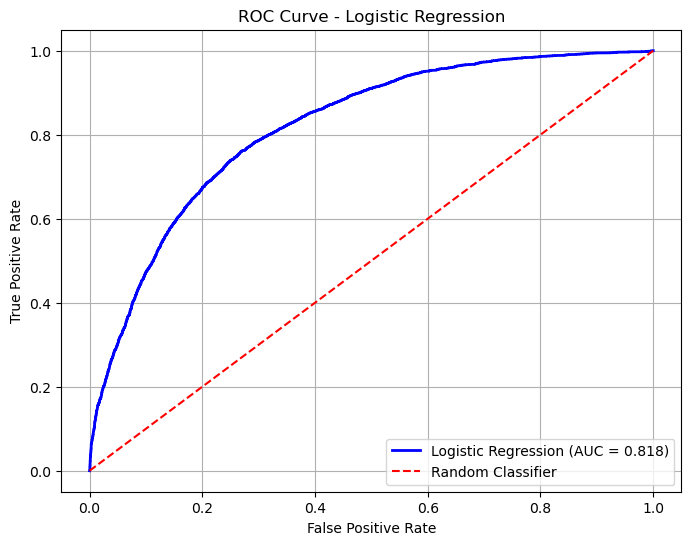

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (Cancelled = 1)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score, 4))

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_score:.3f})')

plt.plot([0,1],[0,1], linestyle='--', color='red', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

### Interpretation

The ROC Curve illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate across different classification thresholds.

The Logistic Regression model achieved a **ROC-AUC Score of 0.8176**, indicating a **good ability** to distinguish between cancelled and non-cancelled hotel bookings.

Key observations:

- A ROC-AUC score of **0.8176** falls within the **Good** classification range.
- The ROC curve remains well above the random classifier line, demonstrating that the model performs significantly better than random guessing.
- Although the model performs well overall, there is still room for improvement using more advanced machine learning algorithms in future weeks.

Overall, Logistic Regression provides a strong baseline model for predicting hotel booking cancellations.